# Tools

In [30]:
import torch
import json
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm

# Setup

In [2]:
# Preset Config
epochs = 20
batch_size = 64
l_r = 0.01
log_interval = 10
random_seed = 1

In [3]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("devices used is: ", device)
print(torch.cuda.get_device_name(0))

devices used is:  cuda
NVIDIA GeForce RTX 3060 Laptop GPU


# Dataset loaded & pre-processed

In [4]:
# Load full MNIST train data
dataset = torchvision.datasets.MNIST(
    root='/mnist_dataset/',
    train=True,
    download=True,
    transform=torchvision.transforms.ToTensor()
)

In [5]:
# Extract and normalize data manually (to allow splitting before wrapping in DataLoader)
data = dataset.data.unsqueeze(1).float() / 255.0 
data = (data - 0.1307) / 0.3081 
full_targets = dataset.targets

# Data split into train/val/test

In [6]:
# Split into 60% train, 20% val, 20% test using scikit learn split
X_train, X_temp, y_train, y_temp = train_test_split(
    data, full_targets, test_size=0.4, random_state=random_seed, stratify=full_targets
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=random_seed, stratify=y_temp
)

# TensorDatasets
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


# Show batch's dimensions & Visualise sample examples

In [7]:
# Show a few test examples
examples = enumerate(test_loader)
batch_idx, (example_data, example_targets) = next(examples)
print("Example batch shape:", example_data.shape)

Example batch shape: torch.Size([64, 1, 28, 28])


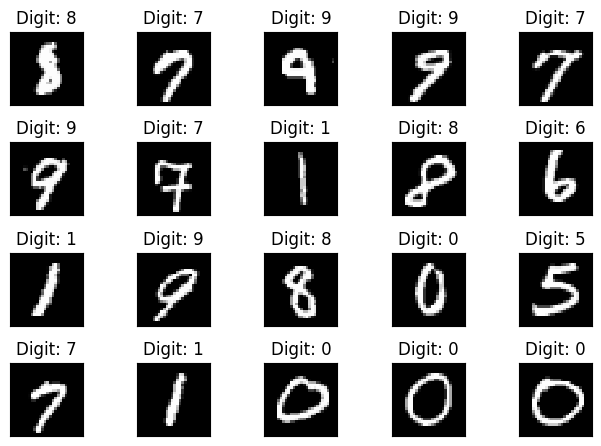

In [8]:
fig = plt.figure()
for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.tight_layout()
    plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
    plt.title("Digit: {}".format(example_targets[i].item()))
    plt.xticks([])
    plt.yticks([])

# Build Neural network using Pytorch 

In [9]:
class FeedfrwdNn(nn.Module):
    def __init__(self, hidden_layers):
        super(FeedfrwdNn, self).__init__()
        self.flatten = nn.Flatten()

        layers = []
        in_features = 28 * 28  # Input size from image

        for hidden_units in hidden_layers:
            layers.append(nn.Linear(in_features, hidden_units))
            layers.append(nn.BatchNorm1d(hidden_units))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.2))
            in_features = hidden_units

        # Output layer: last hidden size → 10 (number of classes)
        layers.append(nn.Linear(in_features, 10))

        # Wrap into Sequential
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        x = self.flatten(x)
        return self.model(x)

# Initiate the Network model along with CE-loss & SGD

In [10]:
# Initialise the network model, loss function and optimizer
model = FeedfrwdNn([512, 256, 128])
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr = l_r)

# Helper functions 

In [11]:
# Function for training
def train(model, train_loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for data, targets in tqdm(train_loader, desc='Training'):
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

    average_loss = running_loss / len(train_loader)
    accuracy = 100. * correct / total
    return average_loss, accuracy

In [12]:
# Function for validating
def validate(model, val_loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, targets in val_loader:
            outputs = model(data)
            loss = criterion(outputs, targets)
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

    average_loss = running_loss / len(val_loader)
    accuracy = 100. * correct / total
    return average_loss, accuracy

# Build Training loop 

In [13]:
# Training loop
def training_loop(model, train_loader, val_loader, optimizer, criterion, epochs):
    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []

    for epoch in range(epochs):
        # Training
        average_loss, train_accuracy = train(model, train_loader, optimizer, criterion)
        train_losses.append(average_loss)
        train_accuracies.append(train_accuracy)

        # Validation
        average_val_loss, val_accuracy = validate(model, val_loader, criterion)
        val_losses.append(average_val_loss)
        val_accuracies.append(val_accuracy)

        # Print metrics
        print(f'Epoch [{epoch + 1}/{epochs}], '
              f'Training Loss: {average_loss:.4f}, Training Accuracy: {train_accuracy:.2f}%, '
              f'Validation Loss: {average_val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%')

    return train_losses, train_accuracies, val_losses, val_accuracies


Base Experiment: for training the dataset with learning rate = 0.01 and batch size = 64

In [14]:
train_losses, train_accuracies, val_losses, val_accuracies = training_loop(model, train_loader, val_loader, optimizer, criterion, epochs)

Training: 100%|██████████| 563/563 [00:02<00:00, 247.98it/s]


Epoch [1/20], Training Loss: 0.7363, Training Accuracy: 81.77%, Validation Loss: 0.2788, Validation Accuracy: 93.03%


Training: 100%|██████████| 563/563 [00:02<00:00, 200.90it/s]


Epoch [2/20], Training Loss: 0.3119, Training Accuracy: 91.69%, Validation Loss: 0.1766, Validation Accuracy: 95.22%


Training: 100%|██████████| 563/563 [00:02<00:00, 210.53it/s]


...

Epoch [18/20], Training Loss: 0.0591, Training Accuracy: 98.21%, Validation Loss: 0.0674, Validation Accuracy: 97.97%


Training: 100%|██████████| 563/563 [00:02<00:00, 248.65it/s]


Epoch [19/20], Training Loss: 0.0586, Training Accuracy: 98.20%, Validation Loss: 0.0654, Validation Accuracy: 98.00%


Training: 100%|██████████| 563/563 [00:02<00:00, 247.50it/s]


Epoch [20/20], Training Loss: 0.0547, Training Accuracy: 98.38%, Validation Loss: 0.0665, Validation Accuracy: 98.06%


# Build train/val loss & train/val accuracy plotting function

In [15]:
def plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies):
    plt.figure(figsize=(12, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Loss per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label='Train Accuracy')
    plt.plot(val_accuracies, label='Validation Accuracy')
    plt.title('Accuracy per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Print final accuracies
    print(f"Final Training Accuracy: {train_accuracies[-1]:.2f}%")
    print(f"Final Validation Accuracy: {val_accuracies[-1]:.2f}%")

Base Experiment: to plot the the model's performance metrics that was previously trained 

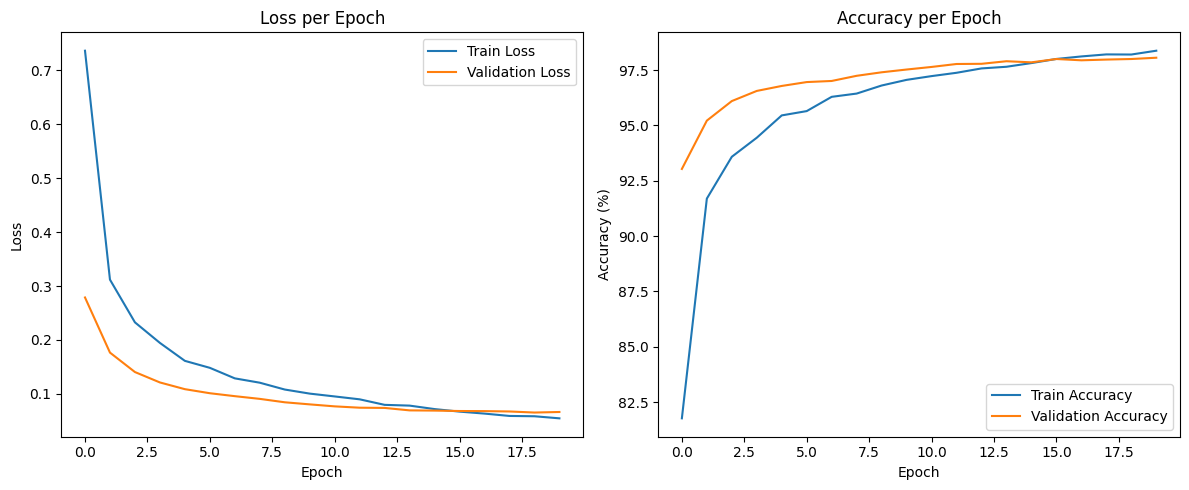

Final Training Accuracy: 98.38%
Final Validation Accuracy: 98.06%


In [16]:
# Plot the results
plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies)

# Analysis Part (1): Evaluate the impact on the model's training and final performance based on the following factors:
* Changing the learning rate, trying 6 different learning rates.
* Changing the batch size, trying 4 different batch sizes.


Testing learning rate: 0.001


Training: 100%|██████████| 563/563 [00:02<00:00, 250.51it/s]


Epoch [1/20], Training Loss: 1.7703, Training Accuracy: 49.06%, Validation Loss: 1.2656, Validation Accuracy: 79.27%


Training: 100%|██████████| 563/563 [00:02<00:00, 246.67it/s]


Epoch [2/20], Training Loss: 1.1507, Training Accuracy: 75.63%, Validation Loss: 0.8714, Validation Accuracy: 85.26%


...

Epoch [18/20], Training Loss: 0.2713, Training Accuracy: 92.73%, Validation Loss: 0.1893, Validation Accuracy: 94.92%


Training: 100%|██████████| 563/563 [00:02<00:00, 241.85it/s]


Epoch [19/20], Training Loss: 0.2614, Training Accuracy: 92.95%, Validation Loss: 0.1824, Validation Accuracy: 95.17%


Training: 100%|██████████| 563/563 [00:02<00:00, 239.01it/s]


Epoch [20/20], Training Loss: 0.2588, Training Accuracy: 92.82%, Validation Loss: 0.1771, Validation Accuracy: 95.28%


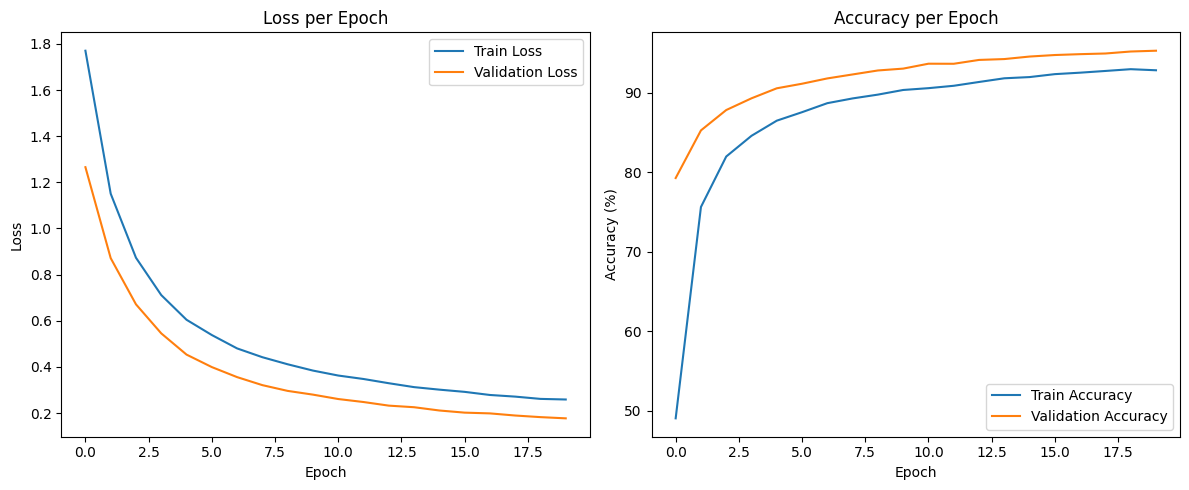

Final Training Accuracy: 92.82%
Final Validation Accuracy: 95.28%

Testing learning rate: 0.003


Training: 100%|██████████| 563/563 [00:02<00:00, 256.23it/s]


Epoch [1/20], Training Loss: 1.2536, Training Accuracy: 68.94%, Validation Loss: 0.6670, Validation Accuracy: 87.80%


Training: 100%|██████████| 563/563 [00:02<00:00, 232.66it/s]


Epoch [2/20], Training Loss: 0.6131, Training Accuracy: 86.05%, Validation Loss: 0.3967, Validation Accuracy: 91.09%


...

Epoch [18/20], Training Loss: 0.1400, Training Accuracy: 95.91%, Validation Loss: 0.1024, Validation Accuracy: 96.91%


Training: 100%|██████████| 563/563 [00:02<00:00, 242.57it/s]


Epoch [19/20], Training Loss: 0.1350, Training Accuracy: 96.12%, Validation Loss: 0.0969, Validation Accuracy: 97.15%


Training: 100%|██████████| 563/563 [00:02<00:00, 242.28it/s]


Epoch [20/20], Training Loss: 0.1262, Training Accuracy: 96.41%, Validation Loss: 0.0962, Validation Accuracy: 97.10%


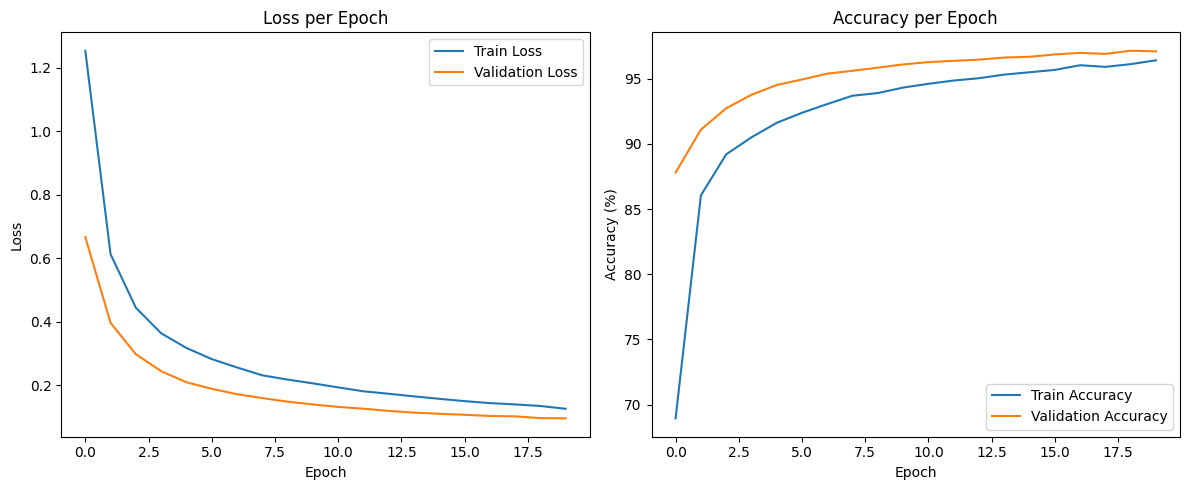

Final Training Accuracy: 96.41%
Final Validation Accuracy: 97.10%

Testing learning rate: 0.01


Training: 100%|██████████| 563/563 [00:02<00:00, 268.26it/s]


Epoch [1/20], Training Loss: 0.7543, Training Accuracy: 81.50%, Validation Loss: 0.2852, Validation Accuracy: 92.92%


Training: 100%|██████████| 563/563 [00:02<00:00, 238.48it/s]


Epoch [2/20], Training Loss: 0.3159, Training Accuracy: 91.59%, Validation Loss: 0.1799, Validation Accuracy: 95.10%


...

Epoch [18/20], Training Loss: 0.0601, Training Accuracy: 98.20%, Validation Loss: 0.0669, Validation Accuracy: 97.98%


Training: 100%|██████████| 563/563 [00:05<00:00, 112.07it/s]


Epoch [19/20], Training Loss: 0.0601, Training Accuracy: 98.19%, Validation Loss: 0.0690, Validation Accuracy: 98.03%


Training: 100%|██████████| 563/563 [00:04<00:00, 113.44it/s]


Epoch [20/20], Training Loss: 0.0550, Training Accuracy: 98.38%, Validation Loss: 0.0670, Validation Accuracy: 98.12%


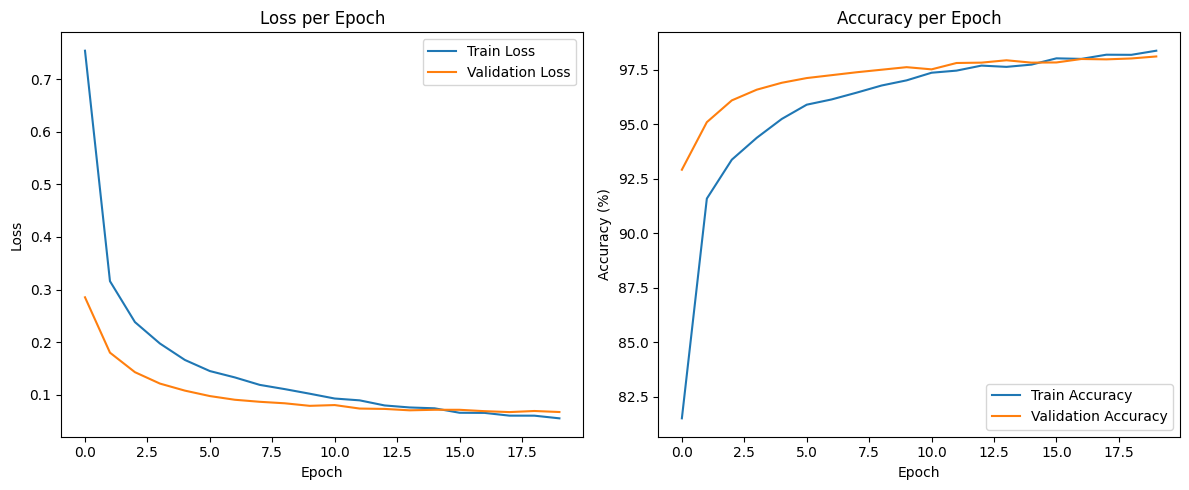

Final Training Accuracy: 98.38%
Final Validation Accuracy: 98.12%

Testing learning rate: 0.03


Training: 100%|██████████| 563/563 [00:04<00:00, 117.28it/s]


Epoch [1/20], Training Loss: 0.4576, Training Accuracy: 88.16%, Validation Loss: 0.1632, Validation Accuracy: 95.44%


Training: 100%|██████████| 563/563 [00:05<00:00, 104.42it/s]


Epoch [2/20], Training Loss: 0.1945, Training Accuracy: 94.39%, Validation Loss: 0.1156, Validation Accuracy: 96.47%


...

Epoch [18/20], Training Loss: 0.0365, Training Accuracy: 98.84%, Validation Loss: 0.0695, Validation Accuracy: 98.05%


Training: 100%|██████████| 563/563 [00:05<00:00, 106.26it/s]


Epoch [19/20], Training Loss: 0.0339, Training Accuracy: 98.91%, Validation Loss: 0.0668, Validation Accuracy: 98.15%


Training: 100%|██████████| 563/563 [00:05<00:00, 107.37it/s]


Epoch [20/20], Training Loss: 0.0306, Training Accuracy: 99.02%, Validation Loss: 0.0625, Validation Accuracy: 98.21%


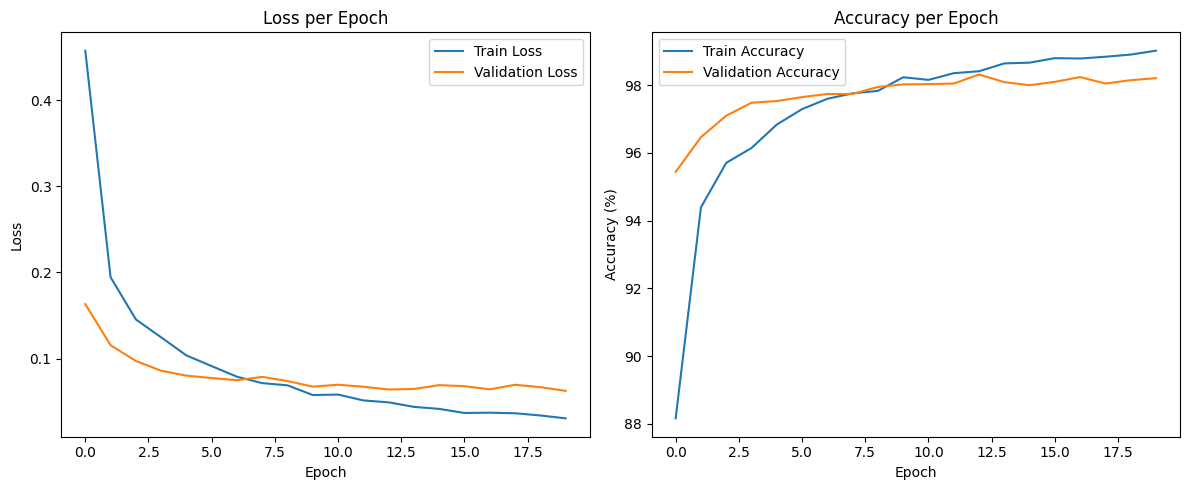

Final Training Accuracy: 99.02%
Final Validation Accuracy: 98.21%

Testing learning rate: 0.1


Training: 100%|██████████| 563/563 [00:05<00:00, 110.56it/s]


Epoch [1/20], Training Loss: 0.3154, Training Accuracy: 90.88%, Validation Loss: 0.1262, Validation Accuracy: 96.17%


Training: 100%|██████████| 563/563 [00:05<00:00, 102.43it/s]


Epoch [2/20], Training Loss: 0.1539, Training Accuracy: 95.41%, Validation Loss: 0.0938, Validation Accuracy: 97.04%


...

Epoch [18/20], Training Loss: 0.0265, Training Accuracy: 99.12%, Validation Loss: 0.0686, Validation Accuracy: 98.18%


Training: 100%|██████████| 563/563 [00:04<00:00, 115.36it/s]


Epoch [19/20], Training Loss: 0.0274, Training Accuracy: 99.14%, Validation Loss: 0.0641, Validation Accuracy: 98.34%


Training: 100%|██████████| 563/563 [00:04<00:00, 113.40it/s]


Epoch [20/20], Training Loss: 0.0241, Training Accuracy: 99.21%, Validation Loss: 0.0612, Validation Accuracy: 98.40%


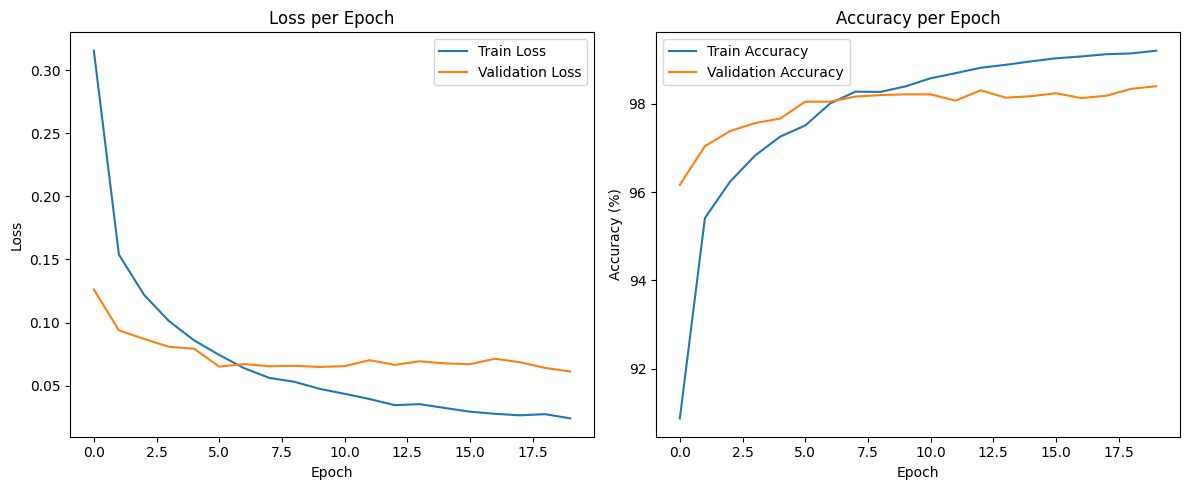

Final Training Accuracy: 99.21%
Final Validation Accuracy: 98.40%

Testing learning rate: 0.3


Training: 100%|██████████| 563/563 [00:04<00:00, 114.01it/s]


Epoch [1/20], Training Loss: 0.2905, Training Accuracy: 91.21%, Validation Loss: 0.1223, Validation Accuracy: 96.63%


Training: 100%|██████████| 563/563 [00:04<00:00, 117.63it/s]


Epoch [2/20], Training Loss: 0.1521, Training Accuracy: 95.36%, Validation Loss: 0.1025, Validation Accuracy: 96.85%


...

Epoch [18/20], Training Loss: 0.0278, Training Accuracy: 99.08%, Validation Loss: 0.0646, Validation Accuracy: 98.35%


Training: 100%|██████████| 563/563 [00:05<00:00, 109.27it/s]


Epoch [19/20], Training Loss: 0.0248, Training Accuracy: 99.21%, Validation Loss: 0.0670, Validation Accuracy: 98.31%


Training: 100%|██████████| 563/563 [00:04<00:00, 112.97it/s]


Epoch [20/20], Training Loss: 0.0204, Training Accuracy: 99.31%, Validation Loss: 0.0642, Validation Accuracy: 98.47%


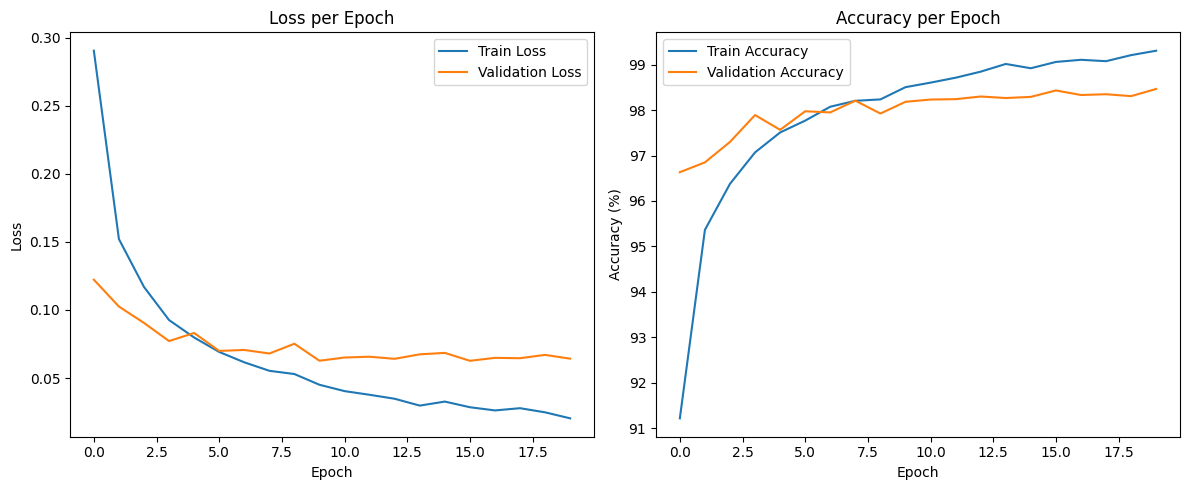

Final Training Accuracy: 99.31%
Final Validation Accuracy: 98.47%


In [18]:
learning_rates = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3]

# Initialize variables to keep track of the best model
final_train_loss, final_val_loss = [], []
final_train_acc, final_val_acc = [], []
best_model = None
best_val_accuracy = 0.0
best_hyperparameters = None

for lr in learning_rates:
    print(f"\nTesting learning rate: {lr}")
    
    model = FeedfrwdNn([512, 256, 128])
    optimizer = optim.SGD(model.parameters(), lr=lr)

    # Training loop executed
    train_losses, train_accuracies, val_losses, val_accuracies = training_loop(
        model, train_loader, val_loader, optimizer, criterion, epochs
    )

    # Plot metrics to be visualised
    plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies)

    # Store final epoch metrics
    final_train_loss.append(train_losses[-1])
    final_val_loss.append(val_losses[-1])
    final_train_acc.append(train_accuracies[-1])
    final_val_acc.append(val_accuracies[-1])

    # Check if current model has the best validation accuracy
    if val_accuracies[-1] > best_val_accuracy:
        best_val_accuracy = val_accuracies[-1]
        best_model = model.state_dict().copy()  # Save model weights
        best_hyperparameters = {'lr': lr}

After comparison done between all models, to find the best learning rate & best model weights to continue using 

In [19]:
# Save best model weights
torch.save(best_model, 'best_model_lr.pth')
# Save best hyperparameters
with open('best_hyperparameter_lr.json', 'w') as f:
    json.dump(best_hyperparameters, f)

# Print the best hyperparameters & best model weights
print("Best Hyperparameter:")
print(best_hyperparameters)
print("\nBest Model:")
print(best_model)

Best Hyperparameter:
{'lr': 0.3}

Best Model:
OrderedDict([('model.0.weight', tensor([[ 3.5696e-03,  2.8699e-02, -1.7840e-02,  ...,  3.6482e-03,
         -2.6643e-02, -3.0546e-02],
        [-3.3791e-02, -1.2750e-02, -6.0501e-03,  ..., -9.9641e-03,
         -1.9831e-02, -3.5546e-02],
        [ 2.1190e-02, -2.4364e-02,  3.0968e-02,  ...,  1.2500e-02,
          1.2944e-02,  2.4299e-05],
        ...,
        [ 2.4278e-04, -8.1763e-03, -9.1318e-03,  ...,  1.8623e-02,
         -8.5072e-04,  1.2349e-02],
        [ 7.9761e-03,  3.1355e-02, -2.9692e-02,  ..., -5.3231e-03,
          6.3212e-03,  3.2112e-02],
        [ 1.1567e-02, -3.0177e-02,  3.0892e-02,  ...,  2.5006e-02,
          3.3567e-02,  2.6660e-02]])), ('model.0.bias', tensor([-1.1880e-02, -2.2512e-02, -2.9132e-02,  2.2540e-02,  3.2135e-02,
        -9.4803e-03, -1.0253e-02,  3.1398e-02,  3.1666e-03,  3.2753e-02,
         2.1238e-02,  1.2164e-02, -7.1593e-03, -2.5265e-04, -1.2143e-02,
         2.3255e-03,  2.2588e-02,  9.0166e-04, -2.53


Testing batch size: 16


Training: 100%|██████████| 2250/2250 [00:14<00:00, 156.91it/s]


Epoch [1/20], Training Loss: 0.5201, Training Accuracy: 85.49%, Validation Loss: 0.1559, Validation Accuracy: 95.76%


Training: 100%|██████████| 2250/2250 [00:13<00:00, 165.54it/s]


Epoch [2/20], Training Loss: 0.2701, Training Accuracy: 92.06%, Validation Loss: 0.1134, Validation Accuracy: 96.69%


...

Epoch [18/20], Training Loss: 0.0727, Training Accuracy: 97.62%, Validation Loss: 0.0643, Validation Accuracy: 98.06%


Training: 100%|██████████| 2250/2250 [00:14<00:00, 156.75it/s]


Epoch [19/20], Training Loss: 0.0725, Training Accuracy: 97.67%, Validation Loss: 0.0588, Validation Accuracy: 98.37%


Training: 100%|██████████| 2250/2250 [00:14<00:00, 150.56it/s]


Epoch [20/20], Training Loss: 0.0680, Training Accuracy: 97.92%, Validation Loss: 0.0618, Validation Accuracy: 98.28%


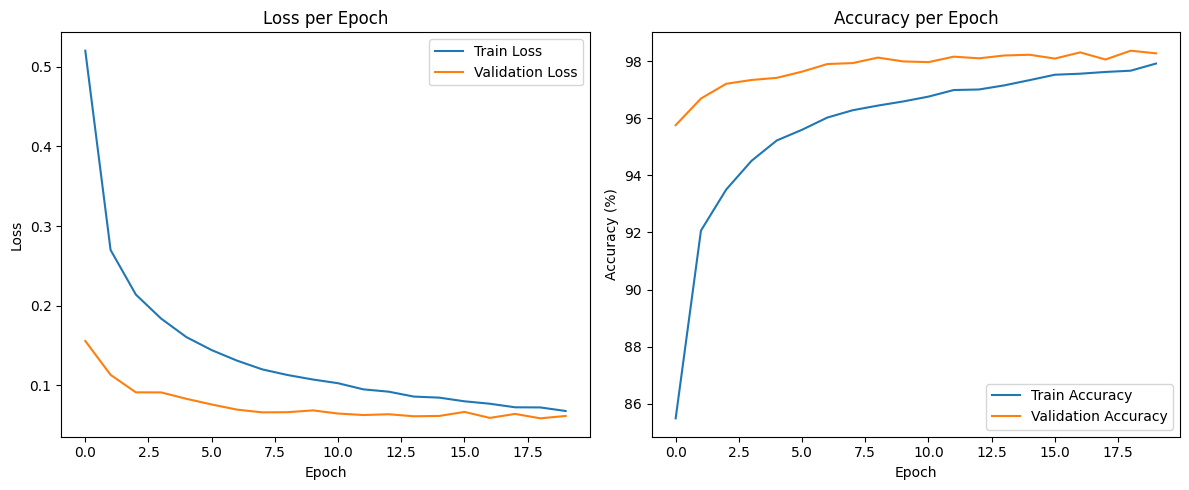

Final Training Accuracy: 97.92%
Final Validation Accuracy: 98.28%

Testing batch size: 32


Training: 100%|██████████| 1125/1125 [00:08<00:00, 129.21it/s]


Epoch [1/20], Training Loss: 0.5762, Training Accuracy: 85.05%, Validation Loss: 0.1925, Validation Accuracy: 94.81%


Training: 100%|██████████| 1125/1125 [00:08<00:00, 130.02it/s]


Epoch [2/20], Training Loss: 0.2584, Training Accuracy: 92.67%, Validation Loss: 0.1312, Validation Accuracy: 96.26%


...

Epoch [18/20], Training Loss: 0.0575, Training Accuracy: 98.20%, Validation Loss: 0.0629, Validation Accuracy: 98.23%


Training: 100%|██████████| 1125/1125 [00:08<00:00, 129.48it/s]


Epoch [19/20], Training Loss: 0.0517, Training Accuracy: 98.43%, Validation Loss: 0.0607, Validation Accuracy: 98.25%


Training: 100%|██████████| 1125/1125 [00:08<00:00, 126.52it/s]


Epoch [20/20], Training Loss: 0.0510, Training Accuracy: 98.39%, Validation Loss: 0.0640, Validation Accuracy: 98.20%


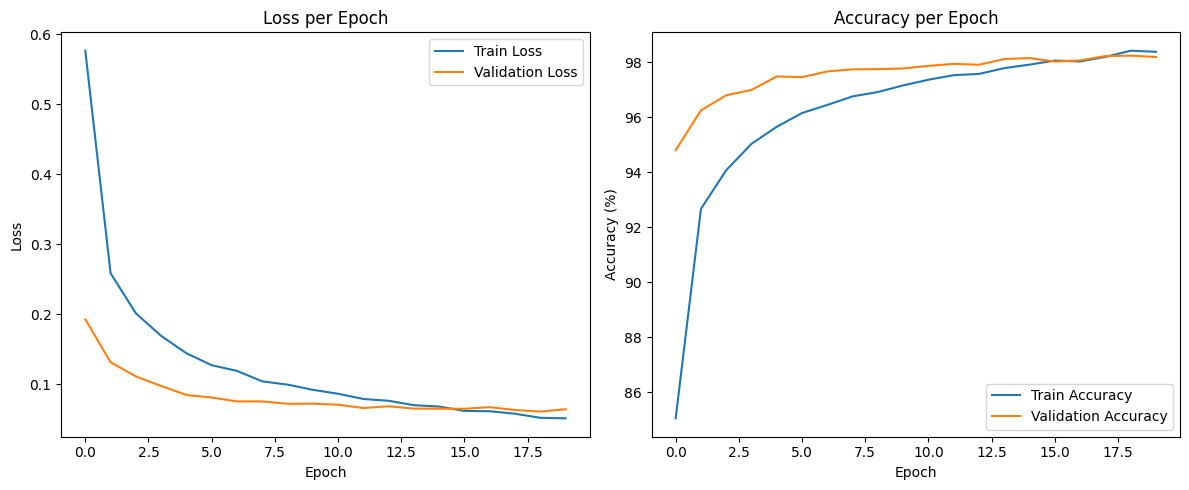

Final Training Accuracy: 98.39%
Final Validation Accuracy: 98.20%

Testing batch size: 64


Training: 100%|██████████| 563/563 [00:04<00:00, 114.02it/s]


Epoch [1/20], Training Loss: 0.7509, Training Accuracy: 81.37%, Validation Loss: 0.2815, Validation Accuracy: 92.95%


Training: 100%|██████████| 563/563 [00:05<00:00, 111.09it/s]


Epoch [2/20], Training Loss: 0.3146, Training Accuracy: 91.55%, Validation Loss: 0.1869, Validation Accuracy: 95.07%


...

Epoch [18/20], Training Loss: 0.0631, Training Accuracy: 98.08%, Validation Loss: 0.0687, Validation Accuracy: 98.03%


Training: 100%|██████████| 563/563 [00:05<00:00, 94.05it/s] 


Epoch [19/20], Training Loss: 0.0593, Training Accuracy: 98.20%, Validation Loss: 0.0709, Validation Accuracy: 97.90%


Training: 100%|██████████| 563/563 [00:04<00:00, 118.88it/s]


Epoch [20/20], Training Loss: 0.0558, Training Accuracy: 98.34%, Validation Loss: 0.0724, Validation Accuracy: 97.81%


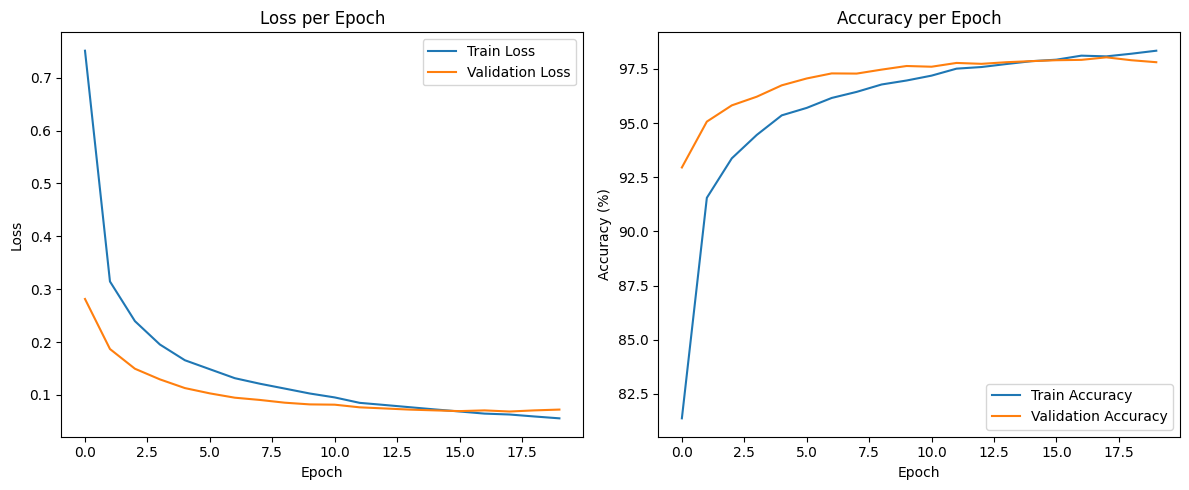

Final Training Accuracy: 98.34%
Final Validation Accuracy: 97.81%

Testing batch size: 128


Training: 100%|██████████| 282/282 [00:03<00:00, 84.43it/s]


Epoch [1/20], Training Loss: 0.9937, Training Accuracy: 75.67%, Validation Loss: 0.4407, Validation Accuracy: 90.76%


Training: 100%|██████████| 282/282 [00:04<00:00, 63.35it/s]


Epoch [2/20], Training Loss: 0.4266, Training Accuracy: 89.73%, Validation Loss: 0.2710, Validation Accuracy: 93.32%


...

Epoch [18/20], Training Loss: 0.0880, Training Accuracy: 97.48%, Validation Loss: 0.0792, Validation Accuracy: 97.59%


Training: 100%|██████████| 282/282 [00:03<00:00, 87.71it/s]


Epoch [19/20], Training Loss: 0.0853, Training Accuracy: 97.49%, Validation Loss: 0.0782, Validation Accuracy: 97.55%


Training: 100%|██████████| 282/282 [00:03<00:00, 85.50it/s]


Epoch [20/20], Training Loss: 0.0794, Training Accuracy: 97.67%, Validation Loss: 0.0770, Validation Accuracy: 97.62%


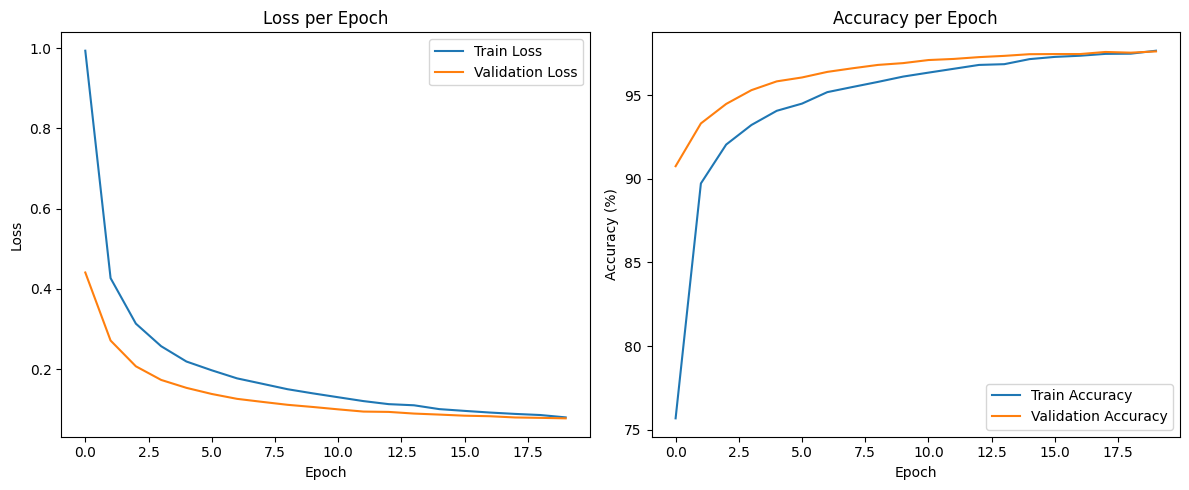

Final Training Accuracy: 97.67%
Final Validation Accuracy: 97.62%


In [21]:
batch_sizes = [16, 32, 64, 128]  
fixed_lr = 0.01

# Initialize variables to keep track of the best model
final_train_loss, final_val_loss = [], []
final_train_acc, final_val_acc = [], []
best_model = None
best_val_accuracy = 0.0
best_hyperparameters = None

for bs in batch_sizes:
    print(f"\nTesting batch size: {bs}")

    # Re-create data loaders with the current batch size
    train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=bs, shuffle=False)

    # Model and optimizer with fixed learning rate
    model = FeedfrwdNn([512, 256, 128])
    optimizer = optim.SGD(model.parameters(), lr=fixed_lr)

    # Training
    train_losses, train_accuracies, val_losses, val_accuracies = training_loop(
        model, train_loader, val_loader, optimizer, criterion, epochs
    )

    # Plot training/validation metrics
    plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies)

    # Save last epoch stats
    final_train_loss.append(train_losses[-1])
    final_val_loss.append(val_losses[-1])
    final_train_acc.append(train_accuracies[-1])
    final_val_acc.append(val_accuracies[-1])

    # Update best model if current one is better
    if val_accuracies[-1] > best_val_accuracy:
        best_val_accuracy = val_accuracies[-1]
        best_model = model.state_dict().copy()
        best_hyperparameters = {'batch_size': bs}

In [22]:
# Save best model weights (from batch size experiment)
torch.save(best_model, 'best_model_batch_size.pth')

# Save best batch size hyperparameters
with open('best_hyperparameter_batch_size.json', 'w') as f:
    json.dump(best_hyperparameters, f)

# Print the best batch size and model state
print("Best Batch Size:")
print(best_hyperparameters)
print("\nBest Model State Dict:")
print(best_model)

Best Batch Size:
{'batch_size': 16}

Best Model State Dict:
OrderedDict([('model.0.weight', tensor([[-1.0750e-02, -3.4728e-02, -3.0347e-03,  ..., -1.0019e-02,
          1.8217e-02, -2.1186e-03],
        [ 5.9347e-03, -2.9878e-02, -1.1317e-02,  ..., -4.0725e-03,
          3.1687e-02, -7.4457e-03],
        [ 2.5983e-02,  9.8061e-03, -6.0248e-03,  ...,  3.0924e-02,
          2.0899e-02,  1.9865e-02],
        ...,
        [-2.1217e-02,  2.8405e-02, -2.4383e-02,  ..., -1.4419e-02,
          3.1760e-02,  1.4717e-02],
        [-1.4200e-02,  9.5720e-03,  2.6982e-02,  ...,  2.2207e-02,
          9.7086e-03,  3.0351e-02],
        [-1.0767e-02,  1.7840e-02,  1.1132e-02,  ..., -2.3292e-02,
          8.5243e-05, -6.8339e-03]])), ('model.0.bias', tensor([ 3.0175e-02, -1.6004e-02,  1.3995e-02,  1.6551e-03, -2.2392e-02,
        -1.6418e-02, -3.4228e-03,  3.1638e-02,  2.5966e-02,  1.4901e-02,
        -6.1408e-03, -3.0948e-02,  1.3223e-02,  2.4101e-02,  7.5000e-04,
        -1.0149e-02, -1.6532e-02, -1.3

# Analysis Part (2): Evaluate the impact on the model's training and final performance based on the following factor:
* Changing number of neurons and layers in your model. Try 4 different
values for each.


Testing architecture: 2_layer_128


Training: 100%|██████████| 282/282 [00:01<00:00, 168.79it/s]


Epoch [1/20], Training Loss: 1.0455, Training Accuracy: 75.11%, Validation Loss: 0.5106, Validation Accuracy: 89.47%


Training: 100%|██████████| 282/282 [00:02<00:00, 116.71it/s]


Epoch [2/20], Training Loss: 0.4852, Training Accuracy: 88.24%, Validation Loss: 0.3329, Validation Accuracy: 92.16%


...

Epoch [18/20], Training Loss: 0.1412, Training Accuracy: 95.87%, Validation Loss: 0.1168, Validation Accuracy: 96.57%


Training: 100%|██████████| 282/282 [00:01<00:00, 166.66it/s]


Epoch [19/20], Training Loss: 0.1362, Training Accuracy: 96.02%, Validation Loss: 0.1140, Validation Accuracy: 96.60%


Training: 100%|██████████| 282/282 [00:01<00:00, 166.37it/s]


Epoch [20/20], Training Loss: 0.1325, Training Accuracy: 96.22%, Validation Loss: 0.1125, Validation Accuracy: 96.51%


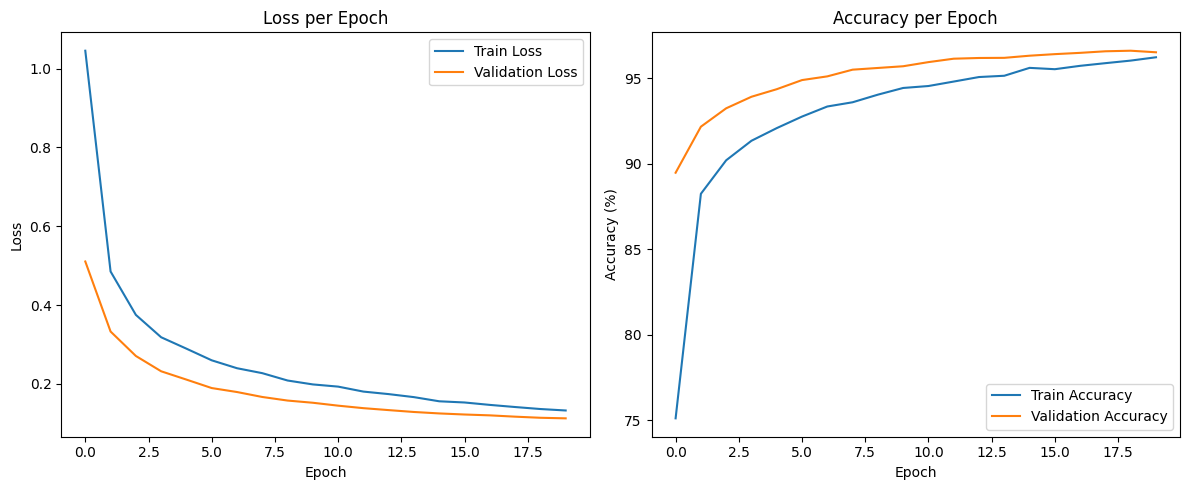

Final Training Accuracy: 96.22%
Final Validation Accuracy: 96.51%

Testing architecture: 3_layer_64_128_64


Training: 100%|██████████| 282/282 [00:01<00:00, 149.38it/s]


Epoch [1/20], Training Loss: 1.3426, Training Accuracy: 65.34%, Validation Loss: 0.7248, Validation Accuracy: 87.42%


Training: 100%|██████████| 282/282 [00:02<00:00, 139.60it/s]


Epoch [2/20], Training Loss: 0.6815, Training Accuracy: 84.98%, Validation Loss: 0.4011, Validation Accuracy: 91.38%


...

Epoch [18/20], Training Loss: 0.2023, Training Accuracy: 94.11%, Validation Loss: 0.1246, Validation Accuracy: 96.22%


Training: 100%|██████████| 282/282 [00:01<00:00, 150.32it/s]


Epoch [19/20], Training Loss: 0.1974, Training Accuracy: 94.38%, Validation Loss: 0.1220, Validation Accuracy: 96.42%


Training: 100%|██████████| 282/282 [00:01<00:00, 150.54it/s]


Epoch [20/20], Training Loss: 0.1920, Training Accuracy: 94.31%, Validation Loss: 0.1224, Validation Accuracy: 96.27%


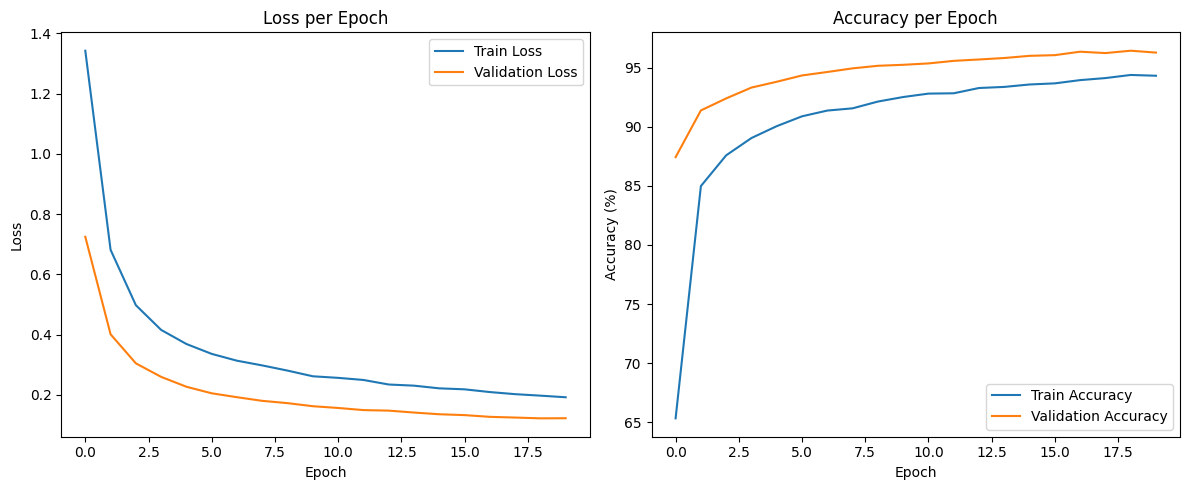

Final Training Accuracy: 94.31%
Final Validation Accuracy: 96.27%

Testing architecture: 2_layer_256


Training: 100%|██████████| 282/282 [00:02<00:00, 116.93it/s]


Epoch [1/20], Training Loss: 0.8642, Training Accuracy: 78.66%, Validation Loss: 0.4083, Validation Accuracy: 90.26%


Training: 100%|██████████| 282/282 [00:02<00:00, 140.00it/s]


Epoch [2/20], Training Loss: 0.3942, Training Accuracy: 89.61%, Validation Loss: 0.2833, Validation Accuracy: 92.67%


...

Epoch [18/20], Training Loss: 0.1040, Training Accuracy: 96.96%, Validation Loss: 0.0988, Validation Accuracy: 97.17%


Training: 100%|██████████| 282/282 [00:02<00:00, 126.60it/s]


Epoch [19/20], Training Loss: 0.0996, Training Accuracy: 97.04%, Validation Loss: 0.0965, Validation Accuracy: 97.13%


Training: 100%|██████████| 282/282 [00:02<00:00, 132.24it/s]


Epoch [20/20], Training Loss: 0.0953, Training Accuracy: 97.25%, Validation Loss: 0.0952, Validation Accuracy: 97.20%


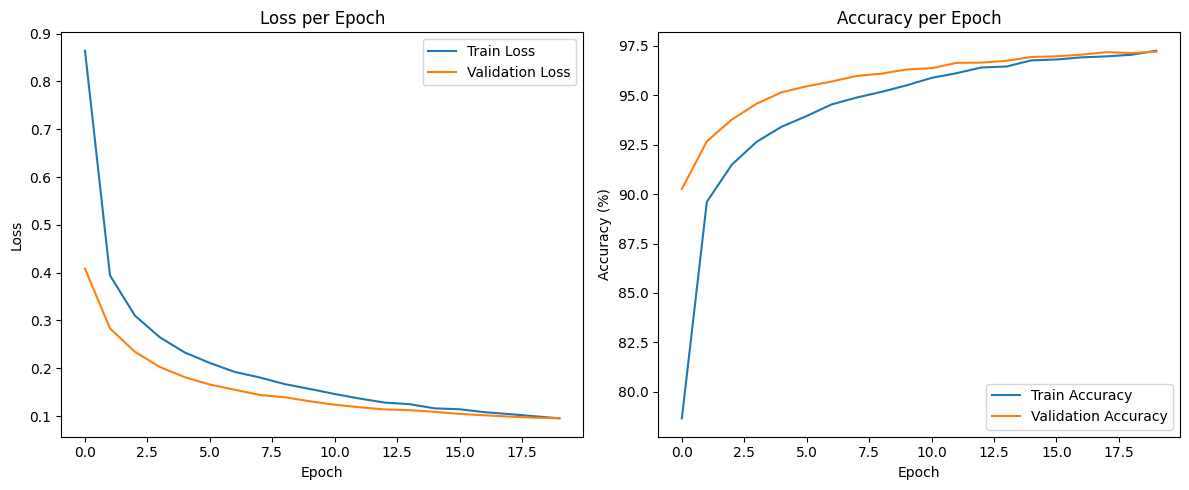

Final Training Accuracy: 97.25%
Final Validation Accuracy: 97.20%

Testing architecture: 3_layer_256_128_64


Training: 100%|██████████| 282/282 [00:02<00:00, 125.35it/s]


Epoch [1/20], Training Loss: 1.2418, Training Accuracy: 69.71%, Validation Loss: 0.6253, Validation Accuracy: 88.47%


Training: 100%|██████████| 282/282 [00:02<00:00, 122.23it/s]


Epoch [2/20], Training Loss: 0.5877, Training Accuracy: 86.88%, Validation Loss: 0.3524, Validation Accuracy: 92.39%


...

Epoch [18/20], Training Loss: 0.1286, Training Accuracy: 96.34%, Validation Loss: 0.0922, Validation Accuracy: 97.22%


Training: 100%|██████████| 282/282 [00:02<00:00, 116.06it/s]


Epoch [19/20], Training Loss: 0.1211, Training Accuracy: 96.57%, Validation Loss: 0.0898, Validation Accuracy: 97.23%


Training: 100%|██████████| 282/282 [00:02<00:00, 120.68it/s]


Epoch [20/20], Training Loss: 0.1169, Training Accuracy: 96.69%, Validation Loss: 0.0900, Validation Accuracy: 97.25%


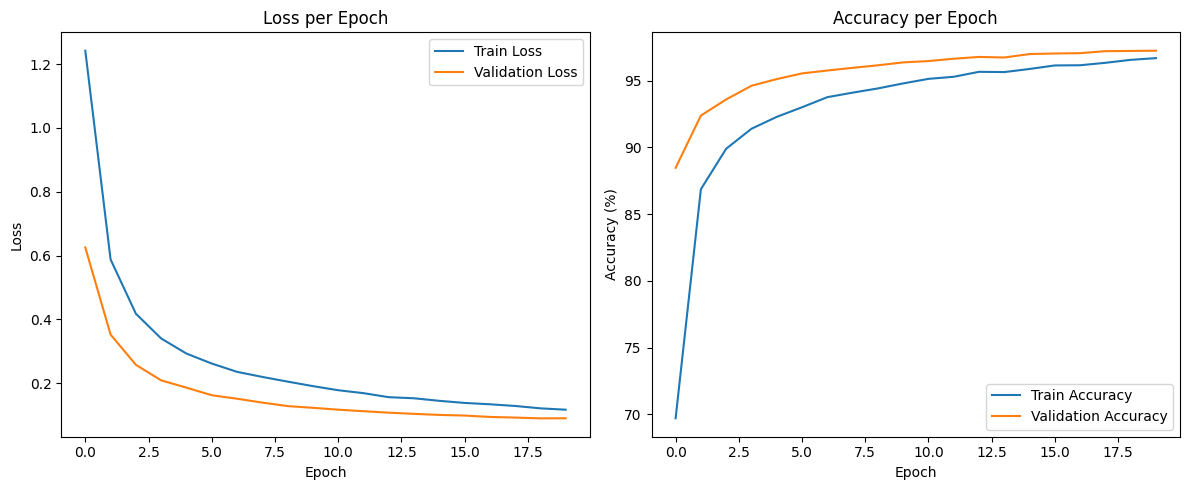

Final Training Accuracy: 96.69%
Final Validation Accuracy: 97.25%


In [24]:
# Define different model variants by architecture
model_variants = {
    "2_layer_128": [128, 128],
    "3_layer_64_128_64": [64, 128, 64],
    "2_layer_256": [256, 256],
    "3_layer_256_128_64": [256, 128, 64],
}

# Storage for results
final_train_loss_arch, final_val_loss_arch = [], []
final_train_acc_arch, final_val_acc_arch = [], []
best_model_arch = None
best_val_accuracy_arch = 0.0
best_architecture = None

for name, layers in model_variants.items():
    print(f"\nTesting architecture: {name}")
    
    model = FeedfrwdNn(hidden_layers=layers)  # updated model with dynamic layers
    optimizer = optim.SGD(model.parameters(), lr=0.01)  # use a stable lr

    train_losses, train_accuracies, val_losses, val_accuracies = training_loop(
        model, train_loader, val_loader, optimizer, criterion, epochs
    )

    plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies)

    final_train_loss_arch.append(train_losses[-1])
    final_val_loss_arch.append(val_losses[-1])
    final_train_acc_arch.append(train_accuracies[-1])
    final_val_acc_arch.append(val_accuracies[-1])

    if val_accuracies[-1] > best_val_accuracy_arch:
        best_val_accuracy_arch = val_accuracies[-1]
        best_model_arch = model.state_dict().copy()
        best_architecture = {"layers": layers, "name": name}


In [25]:
# Save best model weights
torch.save(best_model_arch, 'best_model_arch.pth')
# Save best architecture
with open('best_architecture.json', 'w') as f:
    json.dump(best_architecture, f)

# Print the best batch size and model state
print("Best Architecture:")
print(best_architecture)
print("\nBest Model State Dict:")
print(best_model_arch)

Best Architecture:
{'layers': [256, 128, 64], 'name': '3_layer_256_128_64'}

Best Model State Dict:
OrderedDict([('model.0.weight', tensor([[-0.0034, -0.0065, -0.0270,  ...,  0.0009, -0.0151,  0.0245],
        [ 0.0280,  0.0250, -0.0167,  ..., -0.0246,  0.0223,  0.0213],
        [ 0.0323,  0.0198,  0.0082,  ...,  0.0283,  0.0271,  0.0294],
        ...,
        [-0.0193,  0.0327,  0.0079,  ..., -0.0240, -0.0140, -0.0013],
        [ 0.0058, -0.0232,  0.0024,  ..., -0.0160, -0.0326,  0.0179],
        [ 0.0348,  0.0031,  0.0088,  ...,  0.0279,  0.0048,  0.0113]])), ('model.0.bias', tensor([-3.1510e-03, -3.5682e-02, -2.8101e-02,  1.7180e-02, -3.2501e-02,
        -2.8996e-02,  2.8094e-02, -1.2392e-02, -5.5534e-03, -4.3245e-04,
        -1.4495e-02, -1.7704e-03, -7.6692e-03, -2.5167e-02, -3.0038e-02,
        -2.6200e-02,  9.5993e-04,  4.8096e-03,  4.2247e-03, -2.9238e-02,
        -1.2745e-02, -3.2761e-02, -1.9034e-02, -1.0488e-02,  1.5384e-02,
         8.9286e-03,  3.5008e-02,  2.2617e-02,  2.

# Comparing to find the best model among all

In [26]:
def evaluate_on_test(model, data_loader, device='cpu'):
    model.to(device)
    model.eval()

    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    return accuracy, (all_preds, all_labels)

In [29]:
# Load all three best models
model_variants = {
    "lr": ("best_model_lr.pth", FeedfrwdNn([512, 256, 128])),
    "bs": ("best_model_batch_size.pth", FeedfrwdNn([512, 256, 128])),
    "arch": ("best_model_arch.pth", FeedfrwdNn(hidden_layers=best_architecture["layers"])),
}

best_overall_model = None
best_overall_accuracy = 0.0
best_overall_name = None

for name, (model_path, model) in model_variants.items():
    model.load_state_dict(torch.load(model_path))
    model.eval()
    acc, _ = evaluate_on_test(model, val_loader)  # use validation to pick final best
    print(f"{name} model - Validation Accuracy: {acc:.2f}%")

    if acc > best_overall_accuracy:
        best_overall_accuracy = acc
        best_overall_model = model
        best_overall_name = name
        torch.save(model.state_dict(), "best_model_overall.pth")
print(f"\nBest model based on validation accuracy: '{best_overall_name}' with {best_overall_accuracy:.2f}% accuracy.")


lr model - Validation Accuracy: 98.47%
bs model - Validation Accuracy: 98.28%
arch model - Validation Accuracy: 97.25%

Best model based on validation accuracy: 'lr' with 98.47% accuracy.


# Test the best model on test set, report accuracy & confusion matrix

In [31]:
def visualize_samples_with_predictions(data_loader, num_samples=20, model=None, device='cpu'):
    """
    Visualizes a few samples from the data loader along with their true labels and predictions.

    Args:
        data_loader (DataLoader): PyTorch DataLoader for the dataset.
        num_samples (int): Number of samples to visualize.
        model (torch.nn.Module): Trained PyTorch model.
        device (str or torch.device): Device to run the model on ('cpu' or 'cuda').
    """
    model.eval()  # Set model to evaluation mode
    model.to(device)

    samples_visualized = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            batch_size = images.size(0)
            num_samples_to_visualize = min(num_samples - samples_visualized, batch_size)

            outputs = model(images)
            _, predictions = torch.max(outputs, 1)

            fig, axes = plt.subplots(1, num_samples_to_visualize, figsize=(15, 3))

            for i in range(num_samples_to_visualize):
                img = images[i].cpu().numpy().squeeze()
                label = labels[i].item()
                pred = predictions[i].item()

                ax = axes[i] if num_samples_to_visualize > 1 else axes
                ax.imshow(img, cmap='gray')
                ax.set_title(f"True: {label}\nPred: {pred}")
                ax.axis('off')

            plt.tight_layout()
            plt.show()

            samples_visualized += num_samples_to_visualize

            if samples_visualized >= num_samples:
                break



Test Accuracy of the best model ('lr'): 98.08%


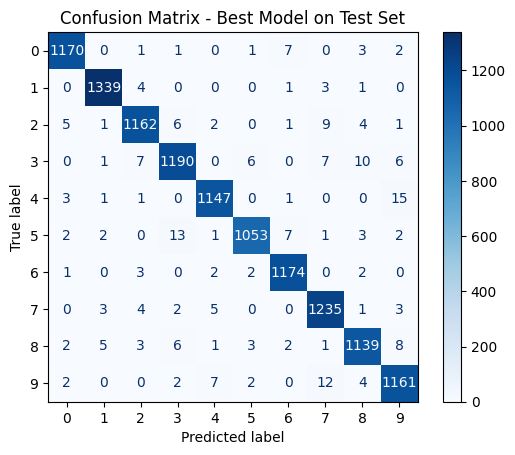

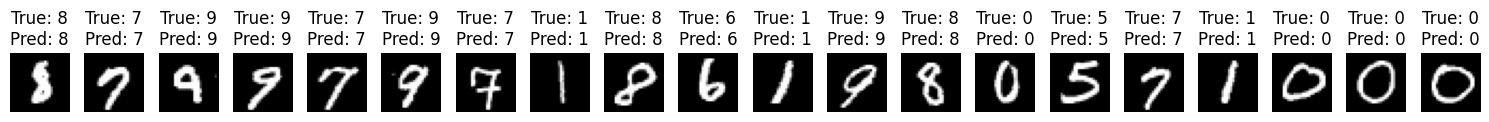

In [32]:
# Evaluate best model on the test set
best_overall_model.eval()
best_overall_model.to(device)
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = best_overall_model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate and print test accuracy
test_accuracy = accuracy_score(all_labels, all_preds) * 100
print(f"\nTest Accuracy of the best model ('{best_overall_name}'): {test_accuracy:.2f}%")

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Best Model on Test Set")
plt.show()

# Visualize predictions
visualize_samples_with_predictions(test_loader, num_samples=20, model=best_overall_model)
